<h1 style="text-align:center;"><b>ECG Multi-Level Classifiaction</b></h1>

In [1]:
pip install tensorflow wfdb pandas numpy scipy scikit-learn matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 3.8 MB/s  0:00:02a 0:00:01m eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.3/35.3 MB 4.1 MB/s  0:00:08 eta 0:00:010:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 4.8 MB/s  0:00:01a 0:00:010:00:01:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 5.1 MB/s  0:00:01 5.4 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 5.2 MB/s  0:00:006.4 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 5.4 MB/s  0:00:00m 5.4 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 5.8 MB/s  0:00:007.0 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 4.4 MB/s  0:00:01m 4.4 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 4.6 MB/s  0:00:00m 6.5 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23/23 [wfdb]37m━ 22/23 [wfdb] [aiohttp]earn]
Note: you may need to restart the kernel to use updated packa

### Check the GPU Support

In [2]:
import tensorflow as tf
print(tf.__version__)

I0000 00:00:1783846978.069816   17889 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1783846978.107688   17889 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1783846978.826385   17889 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


2.21.0


In [3]:
import sys
print(sys.version)

3.12.3 (main, Jun 19 2026, 12:46:00) [GCC 13.3.0]


In [4]:
print("Built with CUDA:", tf.test.is_built_with_cuda())
print("GPU device:", tf.test.gpu_device_name())

Built with CUDA: True
GPU device: 


W0000 00:00:1783847006.880855   17889 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


In [5]:
!pip show tensorflow

Name: tensorflow
Version: 2.21.0
Summary: TensorFlow is an open source machine learning framework for everyone.
Home-page: https://www.tensorflow.org/
Author: Google Inc.
Author-email: packages@tensorflow.org
License: Apache 2.0
Location: /home/tharusha-nimesh/tensorflow-gpu/lib/python3.12/site-packages
Requires: absl-py, astunparse, flatbuffers, gast, google_pasta, grpcio, h5py, keras, libclang, ml_dtypes, numpy, opt_einsum, packaging, protobuf, requests, setuptools, six, termcolor, typing_extensions, wrapt
Required-by: 


In [6]:
print(sys.executable)

/home/tharusha-nimesh/tensorflow-gpu/bin/python3


In [7]:
print(tf.__version__)
print(tf.config.list_physical_devices('GPU'))

2.21.0
[]


W0000 00:00:1783847045.209416   17889 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


# Dataset Download and Project Structure

## Dataset

Download the **PTB-XL ECG Dataset** from PhysioNet:

https://physionet.org/content/ptb-xl/1.0.2/

After downloading and extracting the dataset, organize the project with the following structure:

```
ecg_project/

├── data/
│   ├── ptbxl_database.csv
│   ├── scp_statements.csv
│   └── records500/
│       ├── 00000/
│       ├── 01000/
│       ├── 02000/
│       └── ...
│
├── ECG_classification.ipynb
```

### Directory Description

- **data/**  
  Contains all PTB-XL dataset files.

- **ptbxl_database.csv**  
  Contains metadata information for each ECG recording, including:
  - Patient information
  - Recording identifiers
  - Diagnostic labels
  - Dataset split information

- **scp_statements.csv**  
  Contains the SCP-ECG diagnostic statement mappings and descriptions.

- **records500/**  
  Contains the ECG signal recordings sampled at **500 Hz**.

- **ECG_classification.ipynb**  
  Jupyter Notebook 
 
```

In [2]:
# Import libraries
import numpy as np
import pandas as pd
import tensorflow as tf
import wfdb
import ast

from scipy.signal import butter, filtfilt, iirnotch
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical

Loading Metadata 

In [3]:
print("Loading metadata...")

df = pd.read_csv(
    "data/ptbxl_database.csv",
    index_col="ecg_id"
)

df.scp_codes = df.scp_codes.apply(ast.literal_eval)

Loading metadata...


Load Diagnostic Mappings

In [4]:
scp_df = pd.read_csv(
    "data/scp_statements.csv",
    index_col=0
)

scp_df = scp_df[scp_df.diagnostic == 1]

<h2>Data Preprocessing</h2>

Convert SCP Codes to the 5 Superclasses

# ECG Diagnostic Classes

## 1. NORM — Normal ECG

Records showing no significant electrical abnormality — a structurally and electrically healthy heart rhythm and conduction pattern.

This is the majority class and serves as the baseline against which the other four diagnostic categories are compared.

---

## 2. MI — Myocardial Infarction

Myocardial infarction (acute or recent) refers to heart attack damage, where ECG changes reflect the death of heart muscle tissue due to blocked blood supply.

Subclasses distinguish infarction based on the anatomical location of the affected region of the heart:

- **IMI** — Inferior myocardial infarction
- **AMI** — Anterior myocardial infarction
- **LMI** — Lateral myocardial infarction
- **PMI** — Posterior myocardial infarction

This is clinically the most urgent category and is critical for **STEMI (ST-elevation myocardial infarction) alerts**, which require immediate medical intervention.

---

## 3. STTC — ST/T-Wave Changes

ST/T-wave changes include abnormalities in the ST-segment or T-wave portion of the ECG.

These changes may indicate:
- Reduced blood flow (ischemia) to heart muscle
- Electrolyte imbalances
- Other repolarization abnormalities

Subclasses include:

- **STTC** — General ST/T-wave changes
- **NST_** — Non-specific ST changes
- **ISC_** — Ischemic changes (various subtypes based on location)

This category represents ischemia-related warning signs, which may indicate earlier-stage or ongoing risk signals, unlike MI where tissue damage has already occurred.

---

## 4. CD — Conduction Disturbance

Conduction disturbances refer to abnormalities in how electrical signals travel through the heart's conduction system rather than damage to the heart muscle itself.

Subclasses include:

- **LBBB / RBBB** — Left and right bundle branch block
- **1AVB / 2AVB / 3AVB** — First-, second-, and third-degree atrioventricular block
- **IVCD** — Intraventricular conduction disturbance
- **WPW** — Wolff-Parkinson-White pattern (accessory conduction pathway)

These abnormalities are visible on ECG as changes in:
- QRS complex timing and morphology
- PR interval duration

---

## 5. HYP — Hypertrophy

Hypertrophy refers to enlargement or thickening of the heart muscle, most commonly involving the left ventricle.

Subclasses include:

- **LVH** — Left ventricular hypertrophy
- **RVH** — Right ventricular hypertrophy
- **LAO / LAE** — Left atrial overload/enlargement
- **RAO / RAE** — Right atrial overload/enlargement

Hypertrophy is commonly caused by chronic conditions such as:
- Hypertension
- Heart valve disease

These changes are visible on ECG through abnormal voltage amplitudes and other waveform characteristics.

In [1]:
def aggregate_superclasses(code_dict):

    classes = []

    for key in code_dict.keys():   # If not working, remove .keys()

        if key in scp_df.index:

            c = scp_df.loc[key, "diagnostic_class"]

            if pd.notna(c):
                classes.append(c)

    return list(set(classes))

In [6]:
df["superclasses"] = (
    df.scp_codes.apply(aggregate_superclasses)
)

Keep only records containing at least one superclass

In [7]:
df = df[df.superclasses.apply(len) > 0]

print("Total usable ECGs:", len(df))

Total usable ECGs: 21396


<h3>Multi-Hot Encoding</h3>

In [8]:
# Define the classes
CLASSES = [
    "NORM",
    "MI",
    "STTC",
    "CD",
    "HYP"
]

# Create a mapping:
CLASS_TO_IDX = {
    c: i for i, c in enumerate(CLASSES)
}



In [9]:
# Multi-Hot encoding function

def encode_labels(labels):

    y = np.zeros(len(CLASSES), dtype=np.float32)

    for label in labels:

        if label in CLASS_TO_IDX:
            y[CLASS_TO_IDX[label]] = 1.0

    return y

# <span style="color:red">Important</span>

In [10]:
SELECTED_LEADS = [0]   ## IMPORTANT: Check which lead should be selected based on how we use the 3 electrodes in our module

<h3>FILTERING FUNCTIONS</h3>

In [11]:
def bandpass_filter(signal, fs=500):

    lowcut = 0.5
    highcut = 40.0

    nyquist = fs / 2

    b, a = butter(            # Butterworth filter (IIR)
        4,
        [lowcut / nyquist, highcut / nyquist],
        btype='band'
    )

    return filtfilt(b, a, signal, axis=0)

In [12]:
# Use only if necessary

def notch_filter(signal, fs=500):

    b, a = iirnotch(
        50,     # 50 Hz mains frequency
        30,     # Quality factor
        fs
    )

    return filtfilt(b, a, signal, axis=0)

<H3>Visualize one ECG before and after preprocessing</H3>

Labels: ['HYP', 'STTC', 'MI', 'CD']


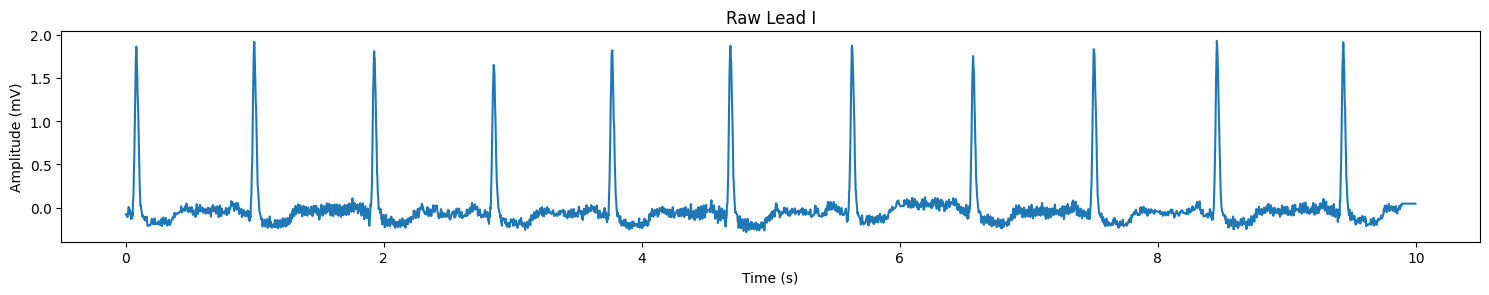

In [13]:
import matplotlib.pyplot as plt

sample_row = df.iloc[1000]

path = f"data/{sample_row.filename_hr}"

print("Labels:", sample_row.superclasses)

signal_raw, meta = wfdb.rdsamp(path)

# Select only the required leads
signal_raw = signal_raw[:, SELECTED_LEADS]

fs = 500
t = np.arange(signal_raw.shape[0]) / fs

lead_names = ["Lead I"]

# Plot raw ECG
plt.figure(figsize=(15, 8))

for i in range(1):

    plt.subplot(3, 1, i + 1)

    plt.plot(t, signal_raw[:, i])

    plt.title(f"Raw {lead_names[i]}")

    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude (mV)")

plt.tight_layout()
plt.show()

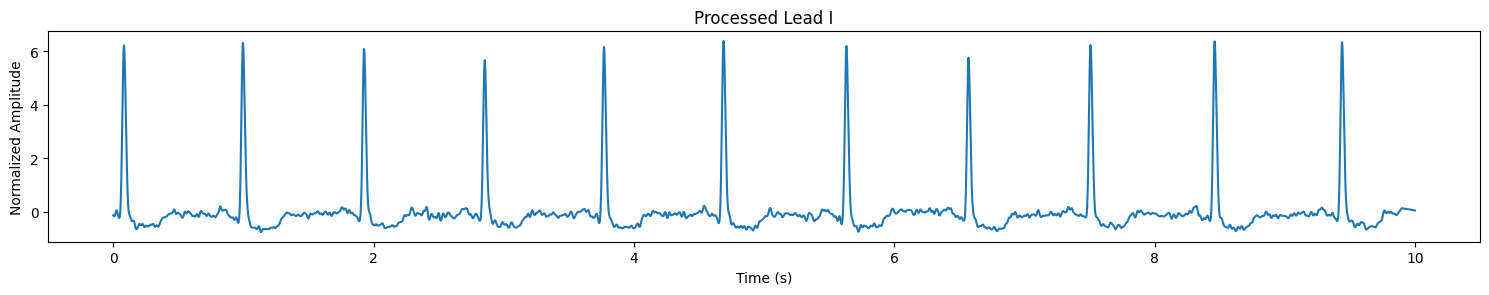

In [14]:
# After preprocessing

# Apply preprocessing manually
signal_processed = bandpass_filter(signal_raw)

signal_processed = notch_filter(signal_processed)

mean = signal_processed.mean(axis=0)
std = signal_processed.std(axis=0)

signal_processed = (signal_processed - mean) / std


# Plot processed ECG
plt.figure(figsize=(15, 8))

for i in range(1):

    plt.subplot(3, 1, i + 1)

    plt.plot(t, signal_processed[:, i])

    plt.title(f"Processed {lead_names[i]}")

    plt.xlabel("Time (s)")
    plt.ylabel("Normalized Amplitude")

plt.tight_layout()
plt.show()

<H3>ECG PREPROCESSING</H3>

In [15]:
def preprocess_ecg(path):

    signal, meta = wfdb.rdsamp(path)

    # Select only required leads
    signal = signal[:, SELECTED_LEADS]

    # Bandpass filtering
    signal = bandpass_filter(signal)

    # Notch filtering
    signal = notch_filter(signal)

    # Per-record z-score normalization
    mean = signal.mean(axis=0)
    std = signal.std(axis=0)

    std[std == 0] = 1e-8

    signal = (signal - mean) / std

    return signal.astype(np.float32)

<h4>DATASET CREATION</h4>

In [16]:
def build_dataset(dataframe):

    X = []
    Y = []

    total = len(dataframe)

    for idx, (_, row) in enumerate(dataframe.iterrows()):

        if idx % 500 == 0:
            print(f"{idx}/{total}")

        path = f"data/{row.filename_hr}"

        signal = preprocess_ecg(path)

        label = encode_labels(row.superclasses)

        X.append(signal)
        Y.append(label)

    X = np.array(X, dtype=np.float32)
    Y = np.array(Y, dtype=np.float32)

    return X, Y

<h4>TRAIN / VALIDATION / TEST SPLITS</h4>

In [17]:
train_df = df[df.strat_fold <= 8]

val_df = df[df.strat_fold == 9]

test_df = df[df.strat_fold == 10]

print("\nTrain:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))


Train: 17090
Validation: 2147
Test: 2159


<h3>Check Class Distribution</h3>

In [18]:
from collections import Counter

counter = Counter()

for labels in train_df["superclasses"]:
    counter.update(labels)

print("\nTraining Set Class Distribution")

for c in CLASSES:
    print(f"{c:5s}: {counter[c]}")


Training Set Class Distribution
NORM : 7598
MI   : 4381
STTC : 4188
CD   : 3909
HYP  : 2119


<h3>Compute class weights</h3>

In [19]:
total_samples = len(train_df)

class_weights = {}

print("\nClass Weights")

for c in CLASSES:

    weight = total_samples / (len(CLASSES) * counter[c])

    class_weights[c] = weight

    print(f"{c:5s}: {weight:.3f}")


Class Weights
NORM : 0.450
MI   : 0.780
STTC : 0.816
CD   : 0.874
HYP  : 1.613


In [20]:
# Convert to a TensorFlow vector

CLASS_WEIGHT_VECTOR = np.array(
    [class_weights[c] for c in CLASSES],
    dtype=np.float32
)

print(CLASS_WEIGHT_VECTOR)

[0.44985524 0.7801872  0.81614137 0.87439245 1.6130251 ]


### Build Numpy arrays

In [21]:
print("\nBuilding training set...")
X_train, y_train = build_dataset(train_df)

print("\nBuilding validation set...")
X_val, y_val = build_dataset(val_df)

print("\nBuilding test set...")
X_test, y_test = build_dataset(test_df)


Building training set...
0/17090
500/17090
1000/17090
1500/17090
2000/17090
2500/17090
3000/17090
3500/17090
4000/17090
4500/17090
5000/17090
5500/17090
6000/17090
6500/17090
7000/17090
7500/17090
8000/17090
8500/17090
9000/17090
9500/17090
10000/17090
10500/17090
11000/17090
11500/17090
12000/17090
12500/17090
13000/17090
13500/17090
14000/17090
14500/17090
15000/17090
15500/17090
16000/17090
16500/17090
17000/17090

Building validation set...
0/2147
500/2147
1000/2147
1500/2147
2000/2147

Building test set...
0/2159
500/2159
1000/2159
1500/2159
2000/2159


In [22]:
# CHECK SHAPES

print("\nShapes:")

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("X_val:", X_val.shape)
print("y_val:", y_val.shape)

print("X_test:", X_test.shape)
print("y_test:", y_test.shape)


Shapes:
X_train: (17090, 5000, 1)
y_train: (17090, 5)
X_val: (2147, 5000, 1)
y_val: (2147, 5)
X_test: (2159, 5000, 1)
y_test: (2159, 5)


In [23]:
# TENSORFLOW DATASETS

BATCH_SIZE = 32

train_ds = (
    tf.data.Dataset
    .from_tensor_slices((X_train, y_train))
    .shuffle(1000)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

val_ds = (
    tf.data.Dataset
    .from_tensor_slices((X_val, y_val))
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

test_ds = (
    tf.data.Dataset
    .from_tensor_slices((X_test, y_test))
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)


print("\nPreprocessing complete!")


Preprocessing complete!


<center><h1>ML Model Implementation</h1></center>

In [24]:
from tensorflow.keras import layers, models, optimizers, losses, metrics

## Custom weighted binary cross-entropy loss

**Use this loss function for all 3 models if the accuracy of the models are less due to the imbalance of the data set.**

In [25]:
weights = tf.constant(CLASS_WEIGHT_VECTOR, dtype=tf.float32)

def weighted_binary_crossentropy(y_true, y_pred):

    bce = tf.keras.backend.binary_crossentropy(y_true, y_pred)

    return tf.reduce_mean(bce * weights)

# Model Architectures

## Model A (ResNet-1D)

1D ResNets are a standard, heavily-used baseline for physiological signal classification (ECG, EEG, PPG).

Residual connections matter here because a plain deep CNN on a 5000-sample signal would suffer from vanishing gradients; skip connections fix that. This is a solid, fast baseline.

---

## Model B (ResNet + BiLSTM)

This is a well-known CNN-LSTM pattern: convolutional layers extract local morphological features (QRS shape, wave amplitudes), then the BiLSTM models how these features evolve and relate across time.

Useful for rhythm-based abnormalities that unfold over the full 10-second window rather than a single beat. This combination appears frequently in ECG arrhythmia literature.

---

## Model C (ResNet + Self-Attention)

This architecture is also well-motivated: attention can directly relate distant timesteps without the sequential bottleneck of an LSTM.

This can help when a diagnostically relevant relationship spans a large portion of the 10-second ECG window. Transformer-based ECG classifiers are an active, published research area.

<h1>Model A: ResNet</h1>

In [26]:
# RESIDUAL BLOCK

def residual_block(x, filters, kernel_sizes=(7, 5), stage_downsample=False):
    """
    A single residual block:
    Conv1D(k=7) -> BN -> ReLU -> Conv1D(k=5) -> BN -> Add(shortcut) -> ReLU

    If the input channel count doesn't match `filters` (e.g. first block
    of a new stage), a 1x1 conv projects the shortcut to match.
    """
    shortcut = x
    in_channels = x.shape[-1]

    # Main path
    y = layers.Conv1D(filters, kernel_sizes[0], padding='same')(x)
    y = layers.BatchNormalization()(y)
    y = layers.ReLU()(y)

    y = layers.Conv1D(filters, kernel_sizes[1], padding='same')(y)
    y = layers.BatchNormalization()(y)

    # Projection shortcut if channel dims differ
    if in_channels != filters:
        shortcut = layers.Conv1D(filters, 1, padding='same')(shortcut)
        shortcut = layers.BatchNormalization()(shortcut)

    out = layers.Add()([y, shortcut])
    out = layers.ReLU()(out)
    return out


def residual_stage(x, filters, n_blocks=2):
    """Stack `n_blocks` residual blocks at a given filter width."""
    for _ in range(n_blocks):
        x = residual_block(x, filters)
    return x

Full Model

In [46]:


def build_resnet1d(input_shape=(5000, 1), num_classes=5):
    inputs = layers.Input(shape=input_shape, name='ecg_input')

    # Stem
    x = layers.Conv1D(64, kernel_size=15, strides=2, padding='same')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    # Stage 1: 64 channels
    x = residual_stage(x, 64, n_blocks=2)
    x = layers.MaxPooling1D(pool_size=2)(x)

    # Stage 2: 128 channels
    x = residual_stage(x, 128, n_blocks=2)
    x = layers.MaxPooling1D(pool_size=2)(x)

    # Stage 3: 256 channels
    x = residual_stage(x, 256, n_blocks=2)
    x = layers.MaxPooling1D(pool_size=2)(x)

    # Stage 4: 512 channels
    x = residual_stage(x, 512, n_blocks=2)

    # Head
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(num_classes, activation='sigmoid', name='predictions')(x)

    model = models.Model(inputs, outputs, name='ResNet1D_ECG')
    return model

<h4>Build the model</h4>

In [48]:
NUM_CLASSES = 5

model_A = build_resnet1d(input_shape=(5000, 1), num_classes=NUM_CLASSES)

optimizer_A = optimizers.Adam(learning_rate=1e-3)

loss_fn = losses.BinaryCrossentropy()     # later set to loss_fn = weighted_binary_crossentropy in case of an imbalance

Compile the model

In [49]:
model_A.compile(
    optimizer=optimizer_A,
    loss=loss_fn,
    metrics=[
        metrics.BinaryAccuracy(name='binary_accuracy'),
        metrics.AUC(name='auc', multi_label=True),
        metrics.Precision(name='precision'),
        metrics.Recall(name='recall'),
    ]
)

model_A.summary()

Model: "ResNet1D_ECG"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ ecg_input (InputLayer)        │ (None, 5000, 3)           │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1d_20 (Conv1D)            │ (None, 2500, 64)          │           2,944 │ ecg_input[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_20        │ (None, 2500, 64)          │             256 │ conv1d_20[0][0]            │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ re_lu_17 (ReLU)               │ (None, 2500, 64)          │               0 │ batch_normalization_20[0]… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1d_21 (Conv1D)            │ (None, 2500, 64)          │          28,736 │ re_lu_17[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_21        │ (None, 2500, 64)          │             256 │ conv1d_21[0][0]            │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ re_lu_18 (ReLU)               │ (None, 2500, 64)          │               0 │ batch_normalization_21[0]… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1d_22 (Conv1D)            │ (None, 2500, 64)          │          20,544 │ re_lu_18[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_22        │ (None, 2500, 64)          │             256 │ conv1d_22[0][0]            │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ add_8 (Add)                   │ (None, 2500, 64)          │               0 │ batch_normalization_22[0]… │
│                               │                           │                 │ re_lu_17[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ re_lu_19 (ReLU)               │ (None, 2500, 64)          │               0 │ add_8[0][0]                │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1d_23 (Conv1D)            │ (None, 2500, 64)          │          28,736 │ re_lu_19[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_23        │ (None, 2500, 64)          │             256 │ conv1d_23[0][0]            │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ re_lu_20 (ReLU)               │ (None, 2500, 64)          │               0 │ batch_normalization_23[0]… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1d_24 (Conv1D)            │ (None, 2500, 64)          │          20,54

 Total params: 7,483,141 (28.55 MB)

 Trainable params: 7,473,541 (28.51 MB)

 Non-trainable params: 9,600 (37.50 KB)

<h3>Train the model</h3>

In [ ]:
EPOCHS = 50

callbacks_A = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_auc', mode='max', patience=8, restore_best_weights=True
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5, patience=4, min_lr=1e-6
    ),
]

history_A = model_A.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks_A
)

<h1>Model B: ResNet + BiLSTM</h1>

The same Residual block above is used.

<h3>FULL MODEL: ResNet feature extractor + BiLSTM</h3>

In [ ]:
def build_resnet_bilstm(input_shape=(5000, 1), num_classes=5):
    inputs = layers.Input(shape=input_shape, name='ecg_input')

    # Stem — downsamples 5000 -> 2500
    x = layers.Conv1D(64, kernel_size=15, strides=2, padding='same')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    # Stage 1: 64 channels, downsample 2500 -> 1250
    x = residual_stage(x, 64, n_blocks=2)
    x = layers.MaxPooling1D(pool_size=2)(x)

    # Stage 2: 128 channels, downsample 1250 -> 625
    x = residual_stage(x, 128, n_blocks=2)
    x = layers.MaxPooling1D(pool_size=2)(x)

    # Stage 3: 256 channels, downsample 625 -> 312
    x = residual_stage(x, 256, n_blocks=2)
    x = layers.MaxPooling1D(pool_size=2)(x)

    # NOTE: stopping conv downsampling here (unlike pure ResNet which had
    # a 4th 512-channel stage). 312 timesteps is a reasonable sequence
    # length to feed a BiLSTM — going to 512 channels + further pooling
    # would leave too few timesteps for the LSTM to model usefully.

    # ---- BiLSTM over the extracted feature sequence ----
    x = layers.Bidirectional(
        layers.LSTM(128, return_sequences=True)
    )(x)
    x = layers.Bidirectional(
        layers.LSTM(64, return_sequences=False)
    )(x)

    # ---- Classification head ----
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(num_classes, activation='sigmoid', name='predictions')(x)

    model = models.Model(inputs, outputs, name='ResNet_BiLSTM_ECG')
    return model

<h3>Build the model</h3>

In [ ]:
NUM_CLASSES = 5

model_B = build_resnet_bilstm(input_shape=(5000, 1), num_classes=NUM_CLASSES)

optimizer_B = optimizers.Adam(learning_rate=1e-3)

loss_fn = losses.BinaryCrossentropy()    # later set to loss_fn = weighted_binary_crossentropy in case of an imbalance

<h3>Compile the model</h3>

In [ ]:
model_B.compile(
    optimizer=optimizer_B,
    loss=loss_fn,
    metrics=[
        metrics.BinaryAccuracy(name='binary_accuracy'),
        metrics.AUC(name='auc', multi_label=True),
        metrics.Precision(name='precision'),
        metrics.Recall(name='recall'),
    ]
)

model_B.summary()

<h3>Train the model</h3>

In [ ]:
EPOCHS = 50

callbacks_B = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_auc', mode='max', patience=8, restore_best_weights=True
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5, patience=4, min_lr=1e-6
    ),
]

history_B = model_B.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks_B
)

<h1>Model C: ResNet + Self-Attention (No LSTM)</h1>

The same Residual block above is used.

<h3>POSITIONAL ENCODING (sinusoidal, as in the original Transformer)</h3>

In [27]:
def positional_encoding(seq_len, d_model):
    positions = np.arange(seq_len)[:, np.newaxis]
    dims = np.arange(d_model)[np.newaxis, :]

    angle_rates = 1 / np.power(10000, (2 * (dims // 2)) / np.float32(d_model))
    angle_rads = positions * angle_rates

    angle_rads[:, 0::2] = np.sin(angle_rads[:, 0::2])
    angle_rads[:, 1::2] = np.cos(angle_rads[:, 1::2])

    return tf.cast(angle_rads[np.newaxis, ...], dtype=tf.float32)  # (1, seq_len, d_model)


<h3>TRANSFORMER-STYLE ENCODER BLOCK (self-attention + feed-forward)</h3>

In [28]:
def transformer_encoder_block(x, d_model, num_heads=4, ff_dim=256, dropout=0.1):
    # Multi-head self-attention with residual connection
    attn_out = layers.MultiHeadAttention(
        num_heads=num_heads, key_dim=d_model // num_heads
    )(x, x)  # query=x, value/key=x -> self-attention
    attn_out = layers.Dropout(dropout)(attn_out)
    x = layers.Add()([x, attn_out])
    x = layers.LayerNormalization(epsilon=1e-6)(x)

    # Feed-forward network with residual connection
    ffn_out = layers.Dense(ff_dim, activation='relu')(x)
    ffn_out = layers.Dense(d_model)(ffn_out)
    ffn_out = layers.Dropout(dropout)(ffn_out)
    x = layers.Add()([x, ffn_out])
    x = layers.LayerNormalization(epsilon=1e-6)(x)

    return x

<h3>FULL MODEL: ResNet feature extractor + Self-Attention</h3>

In [29]:
def build_resnet_attention(input_shape=(5000, 1), num_classes=5,
                             d_model=256, num_heads=4, num_transformer_blocks=2):
    inputs = layers.Input(shape=input_shape, name='ecg_input')

    # Stem — downsamples 5000 -> 2500
    x = layers.Conv1D(64, kernel_size=15, strides=2, padding='same')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    # Stage 1: 64 channels, downsample 2500 -> 1250
    x = residual_stage(x, 64, n_blocks=2)
    x = layers.MaxPooling1D(pool_size=2)(x)

    # Stage 2: 128 channels, downsample 1250 -> 625
    x = residual_stage(x, 128, n_blocks=2)
    x = layers.MaxPooling1D(pool_size=2)(x)

    # Stage 3: 256 channels (= d_model), downsample 625 -> 312
    x = residual_stage(x, 256, n_blocks=2)
    x = layers.MaxPooling1D(pool_size=2)(x)
    # NOTE: stopped conv downsampling at 3 stages (same rationale as
    # BiLSTM version) — keeps a long enough sequence (~156 steps after
    # one more pool, or 312 here) for attention to have something
    # meaningful to attend over.

    seq_len = x.shape[1]   # e.g. 312 (static, known at graph-build time)

    # ---- Positional encoding so attention knows temporal order ----
    pos_encoding = positional_encoding(seq_len, d_model)
    x = x + pos_encoding

    # ---- Self-attention (Transformer encoder) blocks ----
    for _ in range(num_transformer_blocks):
        x = transformer_encoder_block(x, d_model=d_model, num_heads=num_heads, ff_dim=512)

    # ---- Pool the attended sequence into a fixed-size vector ----
    x = layers.GlobalAveragePooling1D()(x)

    # ---- Classification head ----
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(num_classes, activation='sigmoid', name='predictions')(x)

    model = models.Model(inputs, outputs, name='ResNet_Attention_ECG')
    return model

<h3>Build the model</h3>

In [30]:
NUM_CLASSES = 5

model_C = build_resnet_attention(input_shape=(5000, 1), num_classes=NUM_CLASSES)

optimizer_C = optimizers.Adam(learning_rate=1e-3)

loss_fn = losses.BinaryCrossentropy()    # later set to loss_fn = weighted_binary_crossentropy in case of an imbalance

<h3>Compile the model</h3>

In [31]:
model_C.compile(
    optimizer=optimizer_C,
    loss=loss_fn,
    metrics=[
        metrics.BinaryAccuracy(name='binary_accuracy'),
        metrics.AUC(name='auc', multi_label=True),
        metrics.Precision(name='precision'),
        metrics.Recall(name='recall'),
    ]
)

model_C.summary()

Model: "ResNet_Attention_ECG"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ ecg_input (InputLayer)        │ (None, 5000, 1)           │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1d (Conv1D)               │ (None, 2500, 64)          │           1,024 │ ecg_input[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization           │ (None, 2500, 64)          │             256 │ conv1d[0][0]               │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ re_lu (ReLU)                  │ (None, 2500, 64)          │               0 │ batch_normalization[0][0]  │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1d_1 (Conv1D)             │ (None, 2500, 64)          │          28,736 │ re_lu[0][0]                │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_1         │ (None, 2500, 64)          │             256 │ conv1d_1[0][0]             │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ re_lu_1 (ReLU)                │ (None, 2500, 64)          │               0 │ batch_normalization_1[0][… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1d_2 (Conv1D)             │ (None, 2500, 64)          │          20,544 │ re_lu_1[0][0]              │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_2         │ (None, 2500, 64)          │             256 │ conv1d_2[0][0]             │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ add (Add)                     │ (None, 2500, 64)          │               0 │ batch_normalization_2[0][… │
│                               │                           │                 │ re_lu[0][0]                │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ re_lu_2 (ReLU)                │ (None, 2500, 64)          │               0 │ add[0][0]                  │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1d_3 (Conv1D)             │ (None, 2500, 64)          │          28,736 │ re_lu_2[0][0]              │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_3         │ (None, 2500, 64)          │             256 │ conv1d_3[0][0]             │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ re_lu_3 (ReLU)                │ (None, 2500, 64)          │               0 │ batch_normalization_3[0][… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1d_4 (Conv1D)             │ (None, 2500, 64)          │          20,54

 Total params: 2,918,533 (11.13 MB)

 Trainable params: 2,914,053 (11.12 MB)

 Non-trainable params: 4,480 (17.50 KB)

<h3>Train the model</h3>

In [32]:
EPOCHS = 50

callbacks_C = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_auc', mode='max', patience=8, restore_best_weights=True
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5, patience=4, min_lr=1e-6
    ),
]

history_C = model_C.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks_C
)

Epoch 1/50
535/535 ━━━━━━━━━━━━━━━━━━━━ 465s 849ms/step - auc: 0.7218 - binary_accuracy: 0.7912 - loss: 0.4752 - precision: 0.6392 - recall: 0.4361 - val_auc: 0.7857 - val_binary_accuracy: 0.8141 - val_loss: 0.4278 - val_precision: 0.6949 - val_recall: 0.5065 - learning_rate: 0.0010
Epoch 2/50
535/535 ━━━━━━━━━━━━━━━━━━━━ 1363s 3s/step - auc: 0.7675 - binary_accuracy: 0.8137 - loss: 0.4349 - precision: 0.7025 - recall: 0.4754 - val_auc: 0.7938 - val_binary_accuracy: 0.8160 - val_loss: 0.4333 - val_precision: 0.7170 - val_recall: 0.4817 - learning_rate: 0.0010
Epoch 3/50
104/535 ━━━━━━━━━━━━━━━━━━━━ 6:20 882ms/step - auc: 0.7741 - binary_accuracy: 0.8301 - loss: 0.4081 - precision: 0.7386 - recall: 0.5077

KeyboardInterrupt: 

<h2>Thresholding sigmoid outputs to binary predictions</h2>

In [17]:
THRESHOLD = 0.5
LABEL_NAMES = [ "NORM", "MI", "STTC", "CD", "HYP"]

# Function to call on an entire data set
def get_predictions(model, dataset, threshold=THRESHOLD):
    """
    Runs the model on a tf.data.Dataset, returns:
    - y_true: ground-truth labels (N, 5)
    - y_prob: raw sigmoid outputs (N, 5)
    - y_pred: thresholded binary predictions (N, 5)
    """
    y_true = []
    y_prob = []

    for X_batch, y_batch in dataset:
        preds = model.predict(X_batch, verbose=0)
        y_prob.append(preds)
        y_true.append(y_batch.numpy())

    y_true = np.concatenate(y_true, axis=0)
    y_prob = np.concatenate(y_prob, axis=0)
    y_pred = (y_prob >= threshold).astype(int)

    return y_true, y_prob, y_pred


# Function to call on a single data (one ECG signal)
# NOTE: Model expect the input shape (batch_size, 5000, 1)
def predict_single(model, signal, label_names=LABEL_NAMES, threshold=THRESHOLD):
    """
    signal: raw ECG signal, shape (5000, 1) or (5000,)
    Returns: list of predicted label names, plus the raw probabilities
    """
    # Ensure correct shape: (5000, 1)
    signal = np.asarray(signal)
    if signal.ndim == 1:
        signal = signal.reshape(-1, 1)          # (5000,) -> (5000, 1)

    # Add batch dimension: (5000, 1) -> (1, 5000, 1)
    signal_batch = np.expand_dims(signal, axis=0)

    # Predict
    y_prob = model.predict(signal_batch, verbose=0)   # shape (1, 5)
    y_pred = (y_prob >= threshold).astype(int)         # shape (1, 5)

    # Drop the batch dimension since we only have 1 sample
    y_prob = y_prob[0]      # shape (5,)
    y_pred = y_pred[0]      # shape (5,)

    # Map to label names where prediction == 1
    predicted_labels = [label_names[i] for i in range(len(y_pred)) if y_pred[i] == 1]

    return predicted_labels, y_prob, y_pred


def final_output_on_single_data(predicted_labels):
    """Return the label as a string.
        If predicted_labels is empty => label = "UNKNOWN"
        If predicted_labels contains "NORM" + any other label => label = "UNKNOWN"
    Arg:
        predicted_labels (list): predicted label names, e.g. ['MI', 'NORM']
    Return:
        label (str): Label of the signal
    """
    if len(predicted_labels) == 0:
        label = "UNKNOWN"
    elif "NORM" in predicted_labels and len(predicted_labels) > 1:
        label = "UNKNOWN"
    else:
        label = ', '.join(predicted_labels)

    return label

<h2>Computing accuracy, precision, recall, F1</h2>

In [18]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, multilabel_confusion_matrix
)

In [19]:
def evaluate_multilabel(y_true, y_pred, label_names=None, set_name=""):
    """
    Prints subset accuracy, Hamming accuracy, and micro/macro
    precision/recall/F1, plus per-label breakdown.
    """
    n_labels = y_true.shape[1]
    if label_names is None:
        label_names = [f"Label_{i}" for i in range(n_labels)]

    # Two flavors of "accuracy" for multi-label problems
    subset_acc = accuracy_score(y_true, y_pred)                  # exact match
    hamming_acc = (y_true == y_pred).mean()                      # per-label average

    precision_micro = precision_score(y_true, y_pred, average='micro', zero_division=0)
    recall_micro    = recall_score(y_true, y_pred, average='micro', zero_division=0)
    f1_micro        = f1_score(y_true, y_pred, average='micro', zero_division=0)

    precision_macro = precision_score(y_true, y_pred, average='macro', zero_division=0)
    recall_macro    = recall_score(y_true, y_pred, average='macro', zero_division=0)
    f1_macro        = f1_score(y_true, y_pred, average='macro', zero_division=0)

    print(f"\n{'='*60}")
    print(f"Evaluation on: {set_name}")
    print(f"{'='*60}")
    print(f"Subset Accuracy (exact match): {subset_acc:.4f}")
    print(f"Hamming Accuracy (per-label):  {hamming_acc:.4f}")
    print(f"\n--- Micro-averaged (pools all labels together) ---")
    print(f"Precision: {precision_micro:.4f}")
    print(f"Recall:    {recall_micro:.4f}")
    print(f"F1 Score:  {f1_micro:.4f}")
    print(f"\n--- Macro-averaged (unweighted mean across labels) ---")
    print(f"Precision: {precision_macro:.4f}")
    print(f"Recall:    {recall_macro:.4f}")
    print(f"F1 Score:  {f1_macro:.4f}")
    print(f"\n--- Per-label breakdown ---")
    print(classification_report(y_true, y_pred, target_names=label_names, zero_division=0))

    return {
        'subset_accuracy': subset_acc,
        'hamming_accuracy': hamming_acc,
        'precision_micro': precision_micro,
        'recall_micro': recall_micro,
        'f1_micro': f1_micro,
        'precision_macro': precision_macro,
        'recall_macro': recall_macro,
        'f1_macro': f1_macro,
    }

<h3>Running this across all three models and all three splits</h3>

In [ ]:
models_dict = {
    'Model_A_ResNet': model_A,
    'Model_B_ResNet_BiLSTM': model_B,
    'Model_C_ResNet_Attention': model_C,
}

datasets_dict = {
    'Train': train_ds,
    'Validation': val_ds,
    'Test': test_ds,
}

results = {}  # results[model_name][split_name] = metrics dict

for model_name, model in models_dict.items():
    results[model_name] = {}
    for split_name, ds in datasets_dict.items():
        y_true, y_prob, y_pred = get_predictions(model, ds)
        metrics_dict = evaluate_multilabel(
            y_true, y_pred,
            label_names=LABEL_NAMES,
            set_name=f"{model_name} — {split_name}"
        )
        results[model_name][split_name] = metrics_dict

<h3>Summary comparison table across models</h3>

In [ ]:
summary_rows = []
for model_name, splits in results.items():
    for split_name, metrics_dict in splits.items():
        row = {'Model': model_name, 'Split': split_name}
        row.update(metrics_dict)
        summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows)
summary_df = summary_df[[
    'Model', 'Split', 'subset_accuracy', 'hamming_accuracy',
    'precision_micro', 'recall_micro', 'f1_micro',
    'precision_macro', 'recall_macro', 'f1_macro'
]]

print(summary_df.round(4).to_string(index=False))

## Evaluation Considerations

1. **Watch for train vs validation/test gaps**  
   If any model scores near-perfect on the training set but performs noticeably worse on the validation/test set, it indicates **overfitting**. This should be reported alongside the raw performance numbers rather than considering only the test scores in isolation.

2. **Optimize classification thresholds instead of assuming 0.5**  
   A threshold of **0.5** is not necessarily optimal, especially in the presence of class imbalance. If some of the 5 conditions are rare, a fixed threshold may result in poor recall for minority classes even when the model achieves a good raw AUC. Per-label thresholds can be tuned using **precision-recall curves on the validation set**.

3. **Analyze differences between Macro F1 and Micro F1 scores**  
   A large difference between **Macro F1** and **Micro F1** is a useful diagnostic. If Macro F1 is significantly lower than Micro F1, it usually indicates that the model performs well on frequent labels but poorly on rare labels. In such cases, it is important to check the label distribution using:
   
   ```python
   y_train.sum(axis=0)
   ```